<a href="https://colab.research.google.com/github/ramayer/audio-classifier-visualizer/blob/v1.0.2/notebooks/google-colab-example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!uv pip install "audio-classifier-visualizer[all] @ git+https://github.com/ramayer/audio-classifier-visualizer@v1.0.2"

Using Python 3.13.15 environment at: /usr
Resolved 44 packages in 1.02s
Prepared 3 packages in 3.58s
Installed 3 packages in 11ms
 + audio-classifier-visualizer==1.0.2 (from git+https://github.com/ramayer/audio-classifier-visualizer@d32c68943f25341932896956fe11512372ce27e7)
 + einx==0.4.3
 + ssqueezepy==0.6.6


In [4]:
import numpy as np
import IPython.display as ipd

from audio_classifier_visualizer import (
    AudioVisualization,
    ClassifierOutput,
    LabelBox,
    Track,
)


In [5]:

sample_rate = 44100
duration = 10
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)  # Time array

# Frequencies for the scale from middle C (261.63 Hz) to the octave above (523.25 Hz)
frequencies = [261.626, 293.66, 329.63, 349.23, 392.00, 440.00, 493.88, 523.25]
waveform = np.concatenate([0.5 * np.sin(2 * np.pi * f * t[:int(sample_rate * 8 / len(frequencies))]) for f in frequencies])
waveform = np.concatenate([waveform, np.zeros(int(sample_rate * 2))])  # Add 2 seconds of silence at the end
noise_waveform = np.random.normal(0, 0.5, waveform.shape)  # Generate noise with mean 0 and standard deviation 0.5
waveform += noise_waveform  # Add noise to the waveform

ipd.Audio(waveform, rate=sample_rate)


In [6]:
features_per_second = 2
n_classes = len(frequencies) + 1  # +1 for "silence"

logits = np.zeros((features_per_second * 10, n_classes))
for i in range(len(frequencies)):
    logits[i * features_per_second:(i + 1) * features_per_second, i] = 1.0
logits[features_per_second * 8:features_per_second * 10, n_classes - 1] = 1.0
logits += np.random.normal(0, 0.1, logits.shape)
logits *= 10

# numpy softmax -- no torch needed anywhere in the v1.0 API
exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)

class_labels = ['C', 'D', 'E', 'F', 'G', 'A', 'B', 'C', 'silence']

classifier_output = ClassifierOutput(
    probabilities=probabilities,
    feature_rate=features_per_second,
    class_labels=class_labels,
)


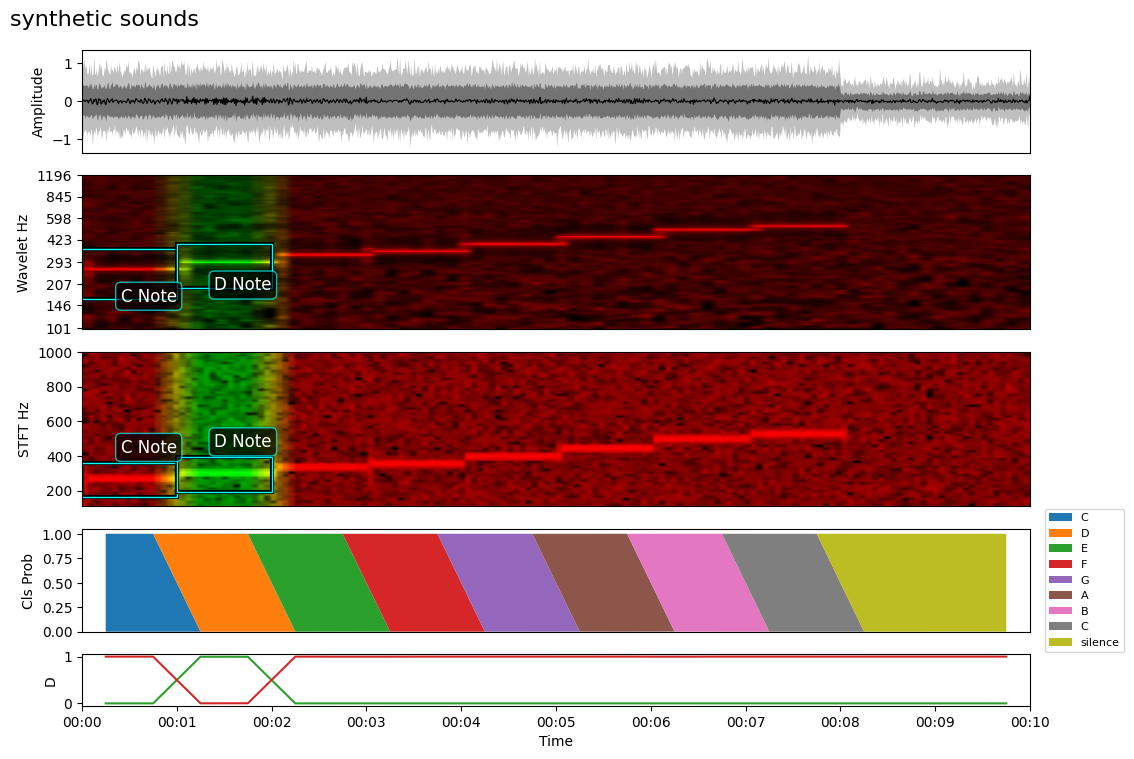

In [7]:
demo_labels = [
    LabelBox(start_time=0, end_time=1, low_freq=frequencies[0] - 100, high_freq=frequencies[0] + 100,
             text="C Note", score=0.95),
    LabelBox(start_time=1, end_time=2, low_freq=frequencies[1] - 100, high_freq=frequencies[1] + 100,
             text="D Note", score=0.85),
]

# The old resample_to_sr=8000 kwarg is now an explicit, visible step (or pass
# target_sr= below) -- loading/resampling and visualization are no longer entangled.
viz = AudioVisualization(
    y=waveform,
    sr=sample_rate,
    target_sr=8000,
    classifier_output=classifier_output,
    labels=demo_labels,
)
viz.stft.n_fft = 512
viz.stft.freq_range_of_interest = (100, 1000)
viz.wavelet.synchrosqueeze = True
viz.show(
    start_time=0,
    end_time=15,
    tracks=(Track.WAVEFORM, Track.WAVELET_SPECTROGRAM, Track.STFT_SPECTROGRAM, Track.CLASS_PROBABILITY_STACK, Track.SIMILARITY_LINES),
    title="synthetic sounds",
    width=12,
    height=8,
    per_channel_normalize=True,
)

# TODO: read https://github.com/OverLordGoldDragon/ssqueezepy/blob/master/ssqueezepy/README.md#performance-guide


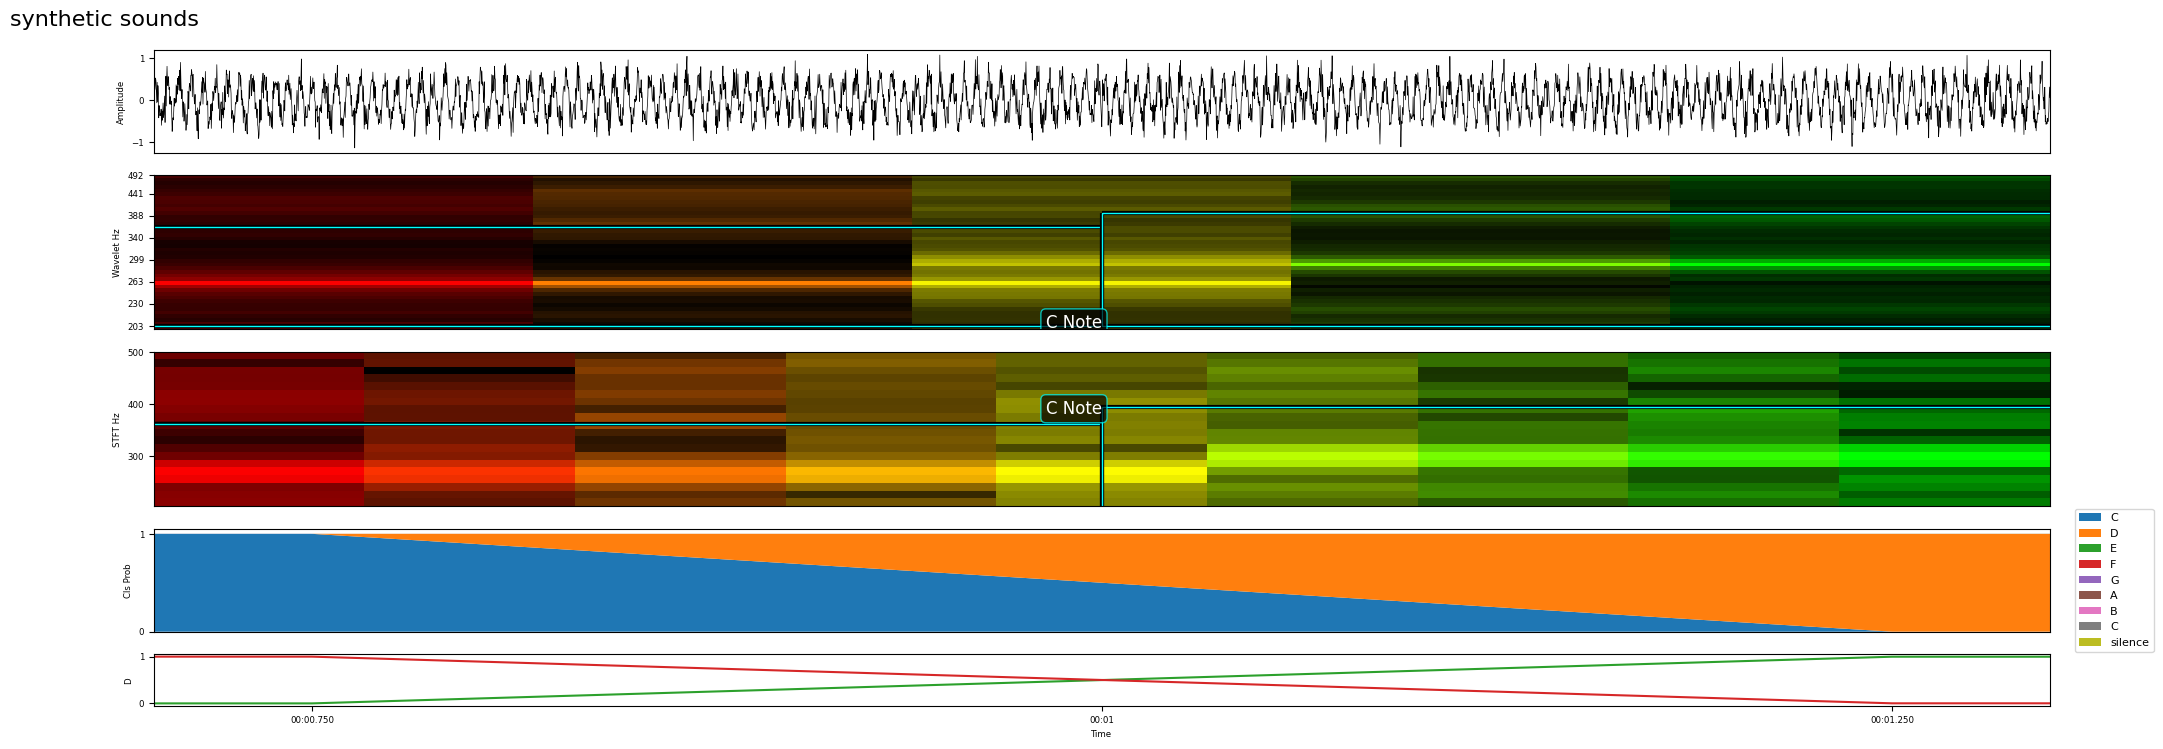

In [8]:
viz.wavelet.freq_range_of_interest = (200, 500)
viz.stft.freq_range_of_interest = (200, 500)
viz.show(
    start_time=0.7,
    end_time=1.3,
    tracks=(Track.WAVEFORM, Track.WAVELET_SPECTROGRAM, Track.STFT_SPECTROGRAM, Track.CLASS_PROBABILITY_STACK, Track.SIMILARITY_LINES),
    title="synthetic sounds",
    width=24,
    height=8,
    per_channel_normalize=False,
)